In [6]:
import pandas as pd
gene_to_idx_plasma = pd.read_csv('PR80_30/gene_to_idx_400_plasma.csv')
gene_to_idx_tissue = pd.read_csv('PR80_30/gene_to_idx_400_tissue.csv')

In [7]:
import torch
tissue_results = torch.load('training_plots/orth_recon_task/explainer_fold_results_tissue.pt', weights_only=False)
plasma_results = torch.load('training_plots/orth_recon_task/explainer_fold_results_plasma.pt', weights_only=False)

C:\Users\P095551\PycharmProjects\AAA_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
graphs_plasma = torch.load("PR80_30/proteins_graphs_400_plasma.pt", weights_only=False)
graphs_tissue = torch.load("PR80_30/proteins_graphs_400_tissue.pt", weights_only=False)

In [9]:

## dir loading
plasma_data = pd.read_excel('PR80_30/plasma_data_imputed_30.xlsx')
tissue_data = pd.read_excel('PR80_30/tissue_data_imputed_30.xlsx')


In [10]:
def node_to_edge_importance(edge_index, node_importance):
    source = edge_index[0]
    target = edge_index[1]

    edge_importance = (
                              node_importance[source] +
                              node_importance[target]
                      ) / 2.0

    return edge_importance


In [22]:
import numpy as np
import gseapy as gp
import igraph

from itertools import combinations

def find_communities_safe(
        edge_index,
        edge_masks=None,
        detection_alg="louvain"
):
    assert detection_alg in [
        "louvain",
        "opt_modularity"
    ]

    edge_index = np.asarray(edge_index, dtype=int)

    if edge_masks is not None:
        edge_masks = np.abs(
            np.asarray(edge_masks, dtype=float)
        )

    edges = [
        (int(row[0]), int(row[1]))
        for row in edge_index.T
    ]

    nodes = set(edge_index.flatten())

    g = igraph.Graph()

    g.add_vertices(max(nodes) + 1)

    g.add_edges(edges)

    if edge_masks is not None:
        g.es["weight"] = edge_masks

    if detection_alg == "louvain":

        partition = g.community_multilevel(
            weights=edge_masks
        )

    elif detection_alg == "opt_modularity":

        partition = g.community_optimal_modularity(
            weights=edge_masks
        )

    valid_communities = []
    avg_edge_masks = []

    for community in partition:

        community = list(community)

        # All possible pairs of nodes in this community
        community_pairs = set(
            combinations(community, r=2)
        )

        # Only retain PPI edges that actually exist
        internal_edges = [
            edge
            for edge in edges
            if edge in community_pairs
        ]

        # Ignore communities without internal PPI edges
        if len(internal_edges) == 0:
            continue

        valid_communities.append(community)

        if edge_masks is not None:

            weights = []

            for edge in internal_edges:
                edge_id = g.get_eid(
                    edge[0],
                    edge[1]
                )

                weights.append(
                    g.es[edge_id]["weight"]
                )

            avg_edge_masks.append(
                np.mean(weights)
            )

    return (
        avg_edge_masks,
        valid_communities
    )



In [35]:

def create_subnetworks(
        explanations_df,
        idx_to_gene,
        edge_index,
        label
):

    all_subnetworks = []

    samples = explanations_df["sample"].unique()

    for sample in samples:

        print(f"\nProcessing {label} | {sample}")

        sample_df = explanations_df[
            explanations_df["sample"] == sample
        ]

        node_importance = (
            sample_df
            .sort_values("idx")
            .set_index("idx")["importance"]
            .reindex(range(len(idx_to_gene)))
            .fillna(0)
            .values
        )

        # Node importance → edge importance
        edge_importance = node_to_edge_importance(
            edge_index,
            node_importance
        )
        threshold = np.percentile(edge_importance, 99)

        keep = edge_importance >= threshold

        edge_index_filtered = edge_index[:, keep]
        edge_importance_filtered = edge_importance[keep]

        # Community detection
        avg_edge_masks, communities = find_communities_safe(
            edge_index=edge_index_filtered,
            edge_masks=edge_importance_filtered,
            detection_alg="louvain"
        )


        print(
            f"Found {len(communities)} {label} communities"
        )
        

        # Store communities
        for community_idx, community in enumerate(communities):

            genes = [
                idx_to_gene[idx]
                for idx in community
                if idx in idx_to_gene
            ]

            all_subnetworks.append({
                "sample": sample,
                "subnetwork": community_idx,
                "n_nodes": len(community),
                "mean_edge_importance": avg_edge_masks[
                    community_idx
                ],
                "genes": genes
            })

    return pd.DataFrame(all_subnetworks)

    # ==================================================
    # Helper: Reactome ORA
    # ==================================================
def create_subnetworks_global(
        explanations_df,
        idx_to_gene,
        edge_index,
        label
):

    all_subnetworks = []
    node_importance = explanations_df.groupby('idx')['importance'].median()
    
    node_importance = (
        node_importance
        .reindex(range(len(idx_to_gene)))
        .fillna(0)
        .values
    )



    # Node importance → edge importance
    edge_importance = node_to_edge_importance(
        edge_index,
        node_importance
    )

    threshold = np.percentile(edge_importance, 99)

    keep = edge_importance >= threshold

    edge_index_filtered = edge_index[:, keep]
    edge_importance_filtered = edge_importance[keep]

    # Community detection
    avg_edge_masks, communities = find_communities_safe(
        edge_index=edge_index_filtered,
        edge_masks=edge_importance_filtered,
        detection_alg="louvain"
    )

    print(
        f"Found {len(communities)} {label} communities"
    )

    # Store communities
    for community_idx, community in enumerate(communities):
        
        genes = [
            idx_to_gene[idx]
            for idx in community
            if idx in idx_to_gene
        ]
        if (len(genes)) < 2:
            continue

        all_subnetworks.append({
            "subnetwork": community_idx,
            "n_nodes": len(community),
            "mean_edge_importance": avg_edge_masks[
                community_idx
            ],
            "genes": genes
        })
        

    return pd.DataFrame(all_subnetworks)
def run_ora(
        subnetworks_df,
        background_genes,
        output_path
):

    ora_results = []

    for _, row in subnetworks_df.iterrows():

        genes = row["genes"]

        if len(genes) == 1:
            continue

        enr = gp.enrichr(
            gene_list=genes,
            gene_sets="Reactome_2022",
            background=background_genes,
            organism="human",
            outdir=None
        )

        results = enr.results.copy()

        #results["sample"] = row["sample"]
        results["subnetwork"] = row["subnetwork"]

        ora_results.append(results)

    if not ora_results:
        print(f"No ORA results for {output_path}")
        return

    ora_df = pd.concat(
        ora_results,
        ignore_index=True
    )

    ora_significant_df = ora_df[
        ora_df["Adjusted P-value"] < 0.05
    ].copy()

    ora_significant_df.to_excel(
        output_path,
        index=False
    )

    print(
        f"Saved {len(ora_significant_df)} significant pathways → "
        f"{output_path}"
    )

In [31]:
######## get neat gnn_explainer results
idx_to_gene_tissue = dict(
    zip(gene_to_idx_tissue["idx"], gene_to_idx_tissue["Gene"])
)
idx_to_gene_plasma = dict(
    zip(gene_to_idx_plasma["idx"], gene_to_idx_plasma["Gene"])
)

g0_plasma = graphs_plasma[0]
g0_tissue = graphs_tissue[0]

edge_index_tissue = g0_tissue.edge_index
edge_index_plasma = g0_plasma.edge_index

tissue_explanations_df = pd.read_csv("training_plots/orth_recon_task/tissue_gnn_explainer_results.csv")
plasma_explanations_df  = pd.read_csv("training_plots/orth_recon_task/plasma_gnn_explainer_results.csv")
tissue_explanations_private_df = pd.read_csv("training_plots/orth_recon_task/tissue_gnn_explainer_results_private.csv")
plasma_explanations_private_df = pd.read_csv("training_plots/orth_recon_task/plasma_gnn_explainer_results_private.csv")

    


In [ ]:
print()

In [32]:

subnetworks_tissue = create_subnetworks(
    tissue_explanations_df,
    idx_to_gene_tissue,
    edge_index_tissue,
    "TISSUE shared"
)

subnetworks_plasma = create_subnetworks(
    plasma_explanations_df,
    idx_to_gene_plasma,
    edge_index_plasma,
    "PLASMA shared"
)

# Private
subnetworks_tissue_private = create_subnetworks(
    tissue_explanations_private_df,
    idx_to_gene_tissue,
    edge_index_tissue,
    "TISSUE private"
)

subnetworks_plasma_private = create_subnetworks(
    plasma_explanations_private_df,
    idx_to_gene_plasma,
    edge_index_plasma,
    "PLASMA private"
)
# ==================================================
# Run ORA
# ==================================================

background_genes_tissue = set(
    idx_to_gene_tissue.values()
)

background_genes_plasma = set(
    idx_to_gene_plasma.values()
)


# Shared tissue
run_ora(
    subnetworks_tissue,
    background_genes_tissue,
    "training_plots/orth_recon_task/tissue_subcommunities_enrichment_results.xlsx"
)


# Shared plasma
run_ora(
    subnetworks_plasma,
    background_genes_plasma,
    "training_plots/orth_recon_task/plasma_subcommunities_enrichment_results.xlsx"
)


# Private tissue
run_ora(
    subnetworks_tissue_private,
    background_genes_tissue,
    "training_plots/orth_recon_task/tissue_private_subcommunities_enrichment_results.xlsx"
)


# Private plasma
run_ora(
    subnetworks_plasma_private,
    background_genes_plasma,
    "training_plots/orth_recon_task/plasma_private_subcommunities_enrichment_results.xlsx"
)


Processing TISSUE shared | Sample 15
Found 5 TISSUE shared communities

Processing TISSUE shared | Sample 17
Found 10 TISSUE shared communities

Processing TISSUE shared | Sample 28
Found 8 TISSUE shared communities

Processing TISSUE shared | Sample 29
Found 5 TISSUE shared communities

Processing TISSUE shared | Sample 34
Found 7 TISSUE shared communities

Processing TISSUE shared | Sample 38
Found 5 TISSUE shared communities

Processing TISSUE shared | Sample 61
Found 9 TISSUE shared communities

Processing TISSUE shared | Sample 76
Found 6 TISSUE shared communities

Processing TISSUE shared | Sample 78
Found 8 TISSUE shared communities

Processing TISSUE shared | Sample 85
Found 5 TISSUE shared communities

Processing TISSUE shared | Sample 88
Found 6 TISSUE shared communities

Processing TISSUE shared | Sample 16
Found 10 TISSUE shared communities

Processing TISSUE shared | Sample 18
Found 5 TISSUE shared communities

Processing TISSUE shared | Sample 22
Found 5 TISSUE shared co

In [36]:

subnetworks_tissue_global = create_subnetworks_global(
    tissue_explanations_df,
    idx_to_gene_tissue,
    edge_index_tissue,
    "TISSUE shared"
)

subnetworks_plasma_global = create_subnetworks_global(
    plasma_explanations_df,
    idx_to_gene_plasma,
    edge_index_plasma,
    "PLASMA shared"
)

# Private
subnetworks_tissue_private_global = create_subnetworks_global(
    tissue_explanations_private_df,
    idx_to_gene_tissue,
    edge_index_tissue,
    "TISSUE private"
)

subnetworks_plasma_private_global = create_subnetworks_global(
    plasma_explanations_private_df,
    idx_to_gene_plasma,
    edge_index_plasma,
    "PLASMA private"
)
# ==================================================
# Run ORA
# ==================================================

background_genes_tissue = set(
    idx_to_gene_tissue.values()
)

background_genes_plasma = set(
    idx_to_gene_plasma.values()
)


# Shared tissue
run_ora(
    subnetworks_tissue_global,
    background_genes_tissue,
    "training_plots/orth_recon_task/tissue_subcommunities_enrichment_results_GLOBAL.xlsx"
)


# Shared plasma
run_ora(
    subnetworks_plasma_global,
    background_genes_plasma,
    "training_plots/orth_recon_task/plasma_subcommunities_enrichment_results_GLOBAL.xlsx"
)


# Private tissue
run_ora(
    subnetworks_tissue_private_global,
    background_genes_tissue,
    "training_plots/orth_recon_task/tissue_private_subcommunities_enrichment_results_GLOBAL.xlsx"
)


# Private plasma
run_ora(
    subnetworks_plasma_private_global,
    background_genes_plasma,
    "training_plots/orth_recon_task/plasma_private_subcommunities_enrichment_results_GLOBAL.xlsx"
)

Found 5 TISSUE shared communities
Found 2 PLASMA shared communities
Found 9 TISSUE private communities
Found 4 PLASMA private communities
Saved 728 significant pathways → training_plots/orth_recon_task/tissue_subcommunities_enrichment_results_GLOBAL.xlsx
Saved 226 significant pathways → training_plots/orth_recon_task/plasma_subcommunities_enrichment_results_GLOBAL.xlsx
Saved 802 significant pathways → training_plots/orth_recon_task/tissue_private_subcommunities_enrichment_results_GLOBAL.xlsx
Saved 43 significant pathways → training_plots/orth_recon_task/plasma_private_subcommunities_enrichment_results_GLOBAL.xlsx


In [37]:
print(len(background_genes_tissue))

6397


In [40]:
subnetworks_tissue_global[subnetworks_tissue_global["subnetwork"]==0].head()

,subnetwork,n_nodes,mean_edge_importance,genes
0,0,220,0.472864,"[SPTAN1, SDC1, CDC37, VCAN, LGALS3, CORO1A, EI..."


In [77]:
plasma_data.columns

Index(['Genes', 'Sample 60', 'Sample 65', 'Sample 18', 'Sample 59',
       'Sample 42', 'Sample 30', 'Sample 31', 'Sample 77', 'Sample 32',
       'Sample 7', 'Sample 55', 'Sample 76', 'Sample 28', 'Sample 72',
       'Sample 88', 'Sample 11', 'Sample 64', 'Sample 25', 'Sample 78',
       'Sample 83', 'Sample 70', 'Sample 90', 'Sample 45', 'Sample 85',
       'Sample 17', 'Sample 22', 'Sample 57', 'Sample 66', 'Sample 38',
       'Sample 82', 'Sample 39', 'Sample 61', 'Sample 16', 'Sample 23',
       'Sample 24', 'Sample 87', 'Sample 73', 'Sample 15', 'Sample 49',
       'Sample 75', 'Sample 79', 'Sample 34', 'Sample 1', 'Sample 36',
       'Sample 29', 'Sample 5', 'Sample 86', 'Sample 52', 'Sample 12',
       'Sample 20', 'Sample 51', 'Sample 48'],
      dtype='str')

In [109]:
tissue_results

{0: {(np.str_('Sample 15'),): Explanation(node_mask=[6397, 1], prediction=[1], target=[1], x=[6397, 1], edge_index=[2, 560456], batch=[6397]),
  (np.str_('Sample 17'),): Explanation(node_mask=[6397, 1], prediction=[1], target=[1], x=[6397, 1], edge_index=[2, 560456], batch=[6397]),
  (np.str_('Sample 28'),): Explanation(node_mask=[6397, 1], prediction=[1], target=[1], x=[6397, 1], edge_index=[2, 560456], batch=[6397]),
  (np.str_('Sample 29'),): Explanation(node_mask=[6397, 1], prediction=[1], target=[1], x=[6397, 1], edge_index=[2, 560456], batch=[6397]),
  (np.str_('Sample 34'),): Explanation(node_mask=[6397, 1], prediction=[1], target=[1], x=[6397, 1], edge_index=[2, 560456], batch=[6397]),
  (np.str_('Sample 38'),): Explanation(node_mask=[6397, 1], prediction=[1], target=[1], x=[6397, 1], edge_index=[2, 560456], batch=[6397]),
  (np.str_('Sample 61'),): Explanation(node_mask=[6397, 1], prediction=[1], target=[1], x=[6397, 1], edge_index=[2, 560456], batch=[6397]),
  (np.str_('Sampl

In [4]:
gene_to_idx_tissue

,Unnamed: 0,Gene,idx
0,0,NHP2,0
1,1,IDH3B,1
2,2,MRPL14,2
3,3,ARHGAP35,3
4,4,SPTAN1,4
...,...,...,...
6392,6392,CDC42BPA,6392
6393,6393,KCTD10,6393
6394,6394,INPP1,6394
6395,6395,BORCS7,6395


In [5]:
import numpy as np

idx_to_gene = dict(
    zip(gene_to_idx_tissue["idx"], gene_to_idx_tissue["Gene"])
)

# Get one explanation
sample_key = list(tissue_results[0].keys())[0]
explanation = tissue_results[0][sample_key]

assert len(gene_to_idx_tissue) == explanation.node_mask.shape[0]
assert list(gene_to_idx_tissue["idx"]) == list(range(6397))

# Node importance
node_importance = explanation.node_mask.detach().cpu().numpy().squeeze()

# Create dataframe
tissue_explanation = pd.DataFrame({
    "idx": np.arange(len(node_importance)),
    "gene": [idx_to_gene[i] for i in range(len(node_importance))],
    "importance": node_importance
})

# Highest importance first
tissue_explanation = tissue_explanation.sort_values(
    "importance",
    ascending=False
)

tissue_explanation.head(20)

,idx,gene,importance
3627,3627,AP3S1,0.909659
4520,4520,ASAH1,0.905306
2546,2546,MSRA,0.904603
5794,5794,TGFB1,0.903735
1720,1720,CCT2,0.903346
1171,1171,PDCD6,0.903064
4455,4455,STX4,0.902176
3485,3485,RBX1,0.900688
105,105,PSMF1,0.899960
3821,3821,BCL2L1,0.899810


In [6]:
all_explanations = []

for fold, fold_results in tissue_results.items():

    for sample_key, explanation in fold_results.items():

        # sample_key is something like ('Sample 15',)
        sample = sample_key[0]

        importance = (
            explanation.node_mask
            .detach()
            .cpu()
            .numpy()
            .squeeze()
        )

        for idx, score in enumerate(importance):

            all_explanations.append({
                "fold": fold,
                "sample": sample,
                "idx": idx,
                "gene": idx_to_gene[idx],
                "importance": score
            })

tissue_explanations_df = pd.DataFrame(all_explanations)

In [7]:
tissue_explanations_df

,fold,sample,idx,gene,importance
0,0,Sample 15,0,NHP2,0.000000
1,0,Sample 15,1,IDH3B,0.000000
2,0,Sample 15,2,MRPL14,0.000000
3,0,Sample 15,3,ARHGAP35,0.000000
4,0,Sample 15,4,SPTAN1,0.147056
...,...,...,...,...,...
332639,4,Sample 90,6392,CDC42BPA,0.000000
332640,4,Sample 90,6393,KCTD10,0.000000
332641,4,Sample 90,6394,INPP1,0.000000
332642,4,Sample 90,6395,BORCS7,0.000000


In [8]:
all_explanations_plasma = []
idx_to_gene_plasma = dict(
    zip(gene_to_idx_plasma["idx"], gene_to_idx_plasma["Gene"])
)
for fold, fold_results in plasma_results.items():

    for sample_key, explanation in fold_results.items():

        # sample_key is something like ('Sample 15',)
        sample = sample_key[0]
        print(sample)

        importance = (
            explanation.node_mask
            .detach()
            .cpu()
            .numpy()
            .squeeze()
        )
        print(importance)

        for idx, score in enumerate(importance):

            all_explanations_plasma.append({
                "fold": fold,
                "sample": sample,
                "idx": idx,
                "gene": idx_to_gene_plasma[idx],
                "importance": score
            })

plasma_explanations_df = pd.DataFrame(all_explanations_plasma)

Sample 15
[0.13088274 0.15366957 0.16599774 ... 0.16365537 0.1257787  0.14162381]
Sample 17
[0.14141598 0.14752807 0.13614169 ... 0.1625958  0.1481577  0.13919914]
Sample 28
[0.15092854 0.13565189 0.14632295 ... 0.14195031 0.13279733 0.13563897]
Sample 29
[0.82334656 0.2279307  0.7949772  ... 0.8600771  0.84542733 0.84652466]
Sample 34
[0.13843319 0.14513448 0.13783829 ... 0.15772066 0.14101471 0.13955076]
Sample 38
[0.16464703 0.16879377 0.16318059 ... 0.17770498 0.1307426  0.14649378]
Sample 61
[0.14558642 0.14399604 0.14236674 ... 0.14084624 0.14607693 0.1457081 ]
Sample 76
[0.82260585 0.82664174 0.79357827 ... 0.8262652  0.18640935 0.7872093 ]
Sample 78
[0.7823571  0.71129733 0.5630981  ... 0.7263884  0.1254646  0.589119  ]
Sample 85
[0.13646492 0.14141238 0.3548163  ... 0.88162196 0.15130343 0.13078558]
Sample 88
[0.15508272 0.8036046  0.7782796  ... 0.80488914 0.14221239 0.82360435]
Sample 16
[0.14714427 0.14221832 0.16432956 ... 0.14195925 0.15736753 0.15259023]
Sample 18
[0.704

In [9]:
print(plasma_explanations_df.head())

   fold     sample  idx    gene  importance
0     0  Sample 15    0    ARF4    0.130883
1     0  Sample 15    1   COX5B    0.153670
2     0  Sample 15    2   AP2S1    0.165998
3     0  Sample 15    3  SPTAN1    0.142831
4     0  Sample 15    4   AP4S1    0.130591


In [10]:
tissue_explanations_df = (tissue_explanations_df.sort_values(['sample','importance'],ascending=[True,False]))
plasma_explanations_df = (plasma_explanations_df.sort_values(['sample','importance'],ascending=[True,False]))


In [45]:
node_importance_tissue = (
    tissue_explanations_df
    .groupby("idx")["importance"]
    .median()
)

In [46]:
g0_tissue = graphs_tissue[0]
# Use the graph topology from one tissue graph
edge_index_tissue = g0_tissue.edge_index

src_tissue = edge_index_tissue[0]
dst_tissue = edge_index_tissue[1]

In [48]:
edge_importance = (
    node_importance_tissue.loc[src_tissue.numpy()].values +
    node_importance_tissue.loc[dst_tissue.numpy()].values
) / 2

In [51]:
print(np.percentile(
    edge_importance,
    [50, 75, 90, 95, 99]
))

[0.         0.07609481 0.14728993 0.17416382 0.41811717]


In [70]:
threshold = np.percentile(edge_importance, 99)

keep = edge_importance >= threshold

edge_index_filtered = edge_index_tissue.numpy()[:, keep]
edge_importance_filtered = edge_importance[keep]

In [100]:
node_importance_plasma = (
    plasma_explanations_df
    .groupby("idx")["importance"]
    .median()
)
g0_plasma = graphs_plasma[0]
# Use the graph topology from one tissue graph
edge_index_plasma = g0_plasma.edge_index

src_plasma = edge_index_plasma[0]
dst_plasma = edge_index_plasma[1]

edge_importance_plasma = (
                          node_importance_plasma.loc[src_plasma.numpy()].values +
                          node_importance_plasma.loc[dst_plasma.numpy()].values
                  ) / 2
print(np.percentile(
    edge_importance_plasma,
    [50, 75, 90, 95, 99]
))
threshold = np.percentile(edge_importance_plasma, 99)

keep = edge_importance_plasma >= threshold

edge_index_filtered_plasma = edge_index_plasma.numpy()[:, keep]
edge_importance_filtered_plasma = edge_importance_plasma[keep]

[0.07944755 0.14595846 0.20518023 0.36849296 0.44639928]


In [72]:
import igraph
import numpy as np
from itertools import combinations
import copy

def find_communities(edge_index, edge_masks, detection_alg='louvain'):
    """
    Creates communities of nodes in a graph based on edge masks and algorithm
    :param edge_index_path: String which contains path to edge_index file
    :param edge_masks_path: String which contains path to edge_mask file
    :param detection_alg: String which decides on algorithm to be used
    return
    Average edge masks per community and communities
    """

    assert detection_alg in ['louvain', 'opt_modularity']

    
    s = list(copy.copy(edge_index[0]))
    t = list(copy.copy(edge_index[1]))

    s.extend(t)
    nodes = list(set(s))

    edges = np.array(edge_index)

    edges = [(row[0], row[1]) for row in edges.T]

    g = igraph.Graph()
    # use max(nodes)+1 for modified datasets for shorter runtime
    # all other cases use len(nodes)
    g.add_vertices(max(nodes)+1)
    #g.add_vertices(len(nodes))
    g.add_edges(edges)
    g.es['weight'] = edge_masks

    if detection_alg == 'louvain':
        partition = g.community_multilevel(weights=edge_masks)
    elif detection_alg == 'opt_modularity':
        partition = g.community_optimal_modularity(weights=edge_masks)
    combs = []
    for i in range(len(partition)):
        cs = []
        for c in combinations(partition[i], r=2):
            cs.append(c)    
        combs.append(sorted(list(set(edges) & set(cs))))

    avg_edge_masks = []
    for com in combs:
        if(len(com) == 0):
            avg_edge_masks.append(np.nan)
            continue
        avg_mask = 0
        if edge_masks is not None:
            count = 0
            for edge in com:
                avg_mask += g.es[g.get_eid(edge[0], edge[1])]['weight']
                count = count + 1
            avg_edge_masks.append(avg_mask/count) 
        
    return avg_edge_masks, partition

In [106]:

avg_mask_plasma, coms_plasma  = find_communities(
    edge_index_filtered_plasma,
    edge_importance_filtered_plasma
)

In [105]:
print(avg_mask)

[nan, nan, nan, np.float32(0.4610505), np.float32(0.45967907), nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float32(0.4884909), nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float32(0.45448878), nan, np.float32(0.45393294), nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, n

In [107]:
import gseapy as gp
pathway_enrich_results = []
for idx, community in enumerate(coms_plasma):
    proteins = [idx_to_gene_plasma[i] for i in community]
    if (len(proteins))<2:
        continue
    

    print(f"\nCommunity {idx}")
    print(f"Mean edge importance: {avg_mask_plasma[idx]:.4f}")
    print(f"Number of proteins: {len(proteins)}")
    print(proteins)
    
    background = list(gene_to_idx_plasma["Gene"])
   

    plasma_pathways = gp.enrichr(
        gene_list=proteins,
        gene_sets=['Reactome_2022'],
        background=background,
        organism='human',
        outdir=None
    )
    results = plasma_pathways.results
    print(results.columns.tolist())
    important_results = results[
    results["Adjusted P-value"] < 0.05
    ]
    for _, pathway in important_results.iterrows():

        pathway_enrich_results.append({
            "Community": idx,
            "Mean edge importance": f'{avg_mask_plasma[idx]:.4f}',
            "Number of proteins": len(proteins),
            "All subnetwork proteins": ";".join(proteins),

            "Pathway": pathway["Term"],
            "P-value": pathway["P-value"],
            "Adjusted P-value": pathway["Adjusted P-value"],
            "Odds Ratio": pathway["Odds Ratio"],
            "Combined Score": pathway["Combined Score"],
            "Genes": pathway["Genes"]
        })

pathway_enrich_df_plasma = pd.DataFrame(pathway_enrich_results)
    


Community 3
Mean edge importance: 0.4611
Number of proteins: 72
['SPTAN1', 'GPX3', 'ANXA2', 'GPI', 'PRDX2', 'LDHA', 'PDIA3', 'ENO2', 'TALDO1', 'UBE2H', 'RBX1', 'BLVRB', 'HSPA9', 'MAPK14', 'CCT5', 'HAGH', 'UQCRFS1', 'HP', 'CALR', 'ACTBL2', 'TPI1', 'HSP90B1', 'ATP5PD', 'PRDX3', 'YWHAG', 'PDIA6', 'SOD2', 'TCP1', 'GLRX3', 'GPX4', 'ORM2', 'P4HB', 'YWHAZ', 'EEF1G', 'DPYSL2', 'ACTG1', 'MMP2', 'YWHAE', 'ATP5F1A', 'PRDX6', 'CANX', 'LAP3', 'GSR', 'APOA1', 'GLO1', 'NDUFS8', 'IDH1', 'SOD3', 'CCT4', 'HSPD1', 'APOE', 'GLRX', 'ALDOA', 'ANXA1', 'GSTO1', 'YWHAB', 'CCT6A', 'ERP44', 'CASP14', 'HSPB1', 'VDAC1', 'ORM1', 'STOM', 'ATP5F1B', 'PGK1', 'PARK7', 'PLG', 'NME1', 'DLD', 'TXNDC5', 'PEBP1', 'CCT7']
['Gene_set', 'Term', 'P-value', 'Adjusted P-value', 'Old P-value', 'Old adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes']

Community 4
Mean edge importance: 0.4651
Number of proteins: 20
['AP4S1', 'APCS', 'PF4', 'SPON1', 'FGG', 'APP', 'CLSTN1', 'ITGB1', 'GNAI2', 'HSD17B10', 'BCHE', 'HSPA5', 'APOC

In [103]:
pathway_enrich_df_plasma.head(500)

,Community,Mean edge importance,Number of proteins,All subnetwork proteins,Pathway,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,3,0.4611,71,SPTAN1;GPX3;ANXA2;GPI;PRDX2;LDHA;PDIA3;ENO2;TA...,Detoxification Of Reactive Oxygen Species R-HS...,4.630576e-07,0.000192,58.476923,852.910153,PRDX3;PRDX2;GPX3;GSR;P4HB;SOD3
1,3,0.4611,71,SPTAN1;GPX3;ANXA2;GPI;PRDX2;LDHA;PDIA3;ENO2;TA...,Association Of TriC/CCT With Target Proteins D...,2.095820e-06,0.000217,96.060606,1256.046741,CCT6A;TCP1;CCT7;CCT5;CCT4
2,3,0.4611,71,SPTAN1;GPX3;ANXA2;GPI;PRDX2;LDHA;PDIA3;ENO2;TA...,Folding Of Actin By CCT/TriC R-HSA-390450,2.095820e-06,0.000217,96.060606,1256.046741,CCT6A;TCP1;CCT7;CCT5;CCT4
3,3,0.4611,71,SPTAN1;GPX3;ANXA2;GPI;PRDX2;LDHA;PDIA3;ENO2;TA...,Mitochondrial Protein Import R-HSA-1268020,2.095820e-06,0.000217,96.060606,1256.046741,HSPA9;ATP5F1A;ATP5F1B;VDAC1;HSPD1
4,3,0.4611,71,SPTAN1;GPX3;ANXA2;GPI;PRDX2;LDHA;PDIA3;ENO2;TA...,Organelle Biogenesis And Maintenance R-HSA-185...,7.764216e-06,0.000643,7.837327,92.213868,HSPA9;YWHAE;ATP5F1A;ATP5PD;ATP5F1B;TCP1;MAPK14...
...,...,...,...,...,...,...,...,...,...,...
118,240,0.4821,11,PF4;CALR;PLEC;PSMB8;ITGB1;GNAI2;MMP9;TGFB1;SLC...,MET Activates PTK2 Signaling R-HSA-8874081,1.258803e-03,0.037554,58.844444,392.939306,ITGB1;SRC
119,240,0.4821,11,PF4;CALR;PLEC;PSMB8;ITGB1;GNAI2;MMP9;TGFB1;SLC...,Disease R-HSA-1643685,1.589780e-03,0.042727,7.406496,47.728642,ITGB1;TGFB1;SRC;SLC2A1;CALR;PSMB8;GNAI2
120,240,0.4821,11,PF4;CALR;PLEC;PSMB8;ITGB1;GNAI2;MMP9;TGFB1;SLC...,Signaling By SCF-KIT R-HSA-1433557,1.670881e-03,0.042727,49.000000,313.325816,SRC;MMP9
121,240,0.4821,11,PF4;CALR;PLEC;PSMB8;ITGB1;GNAI2;MMP9;TGFB1;SLC...,Cell-Cell Communication R-HSA-1500931,2.145144e-03,0.047998,15.701613,96.479324,ITGB1;SRC;PLEC


In [94]:
for community, group in pathway_enrich_df.groupby("Community"):

    print(f"\nCommunity {community}")
    
    print("-" * 60)

    for pathway in group["Pathway"]:
        print(pathway)


Community 4
------------------------------------------------------------
Signal Transduction R-HSA-162582
Signaling By Rho GTPases R-HSA-194315
Signaling By Rho GTPases, Miro GTPases And RHOBTB3 R-HSA-9716542
Hemostasis R-HSA-109582
Platelet Activation, Signaling And Aggregation R-HSA-76002
Immune System R-HSA-168256
Innate Immune System R-HSA-168249
RHO GTPase Cycle R-HSA-9012999
Nervous System Development R-HSA-9675108
Axon Guidance R-HSA-422475
RHO GTPase Effectors R-HSA-195258
Disease R-HSA-1643685
Neutrophil Degranulation R-HSA-6798695
EPH-Ephrin Signaling R-HSA-2682334
Signaling By Receptor Tyrosine Kinases R-HSA-9006934
FCGR3A-mediated Phagocytosis R-HSA-9664422
Regulation Of Actin Dynamics For Phagocytic Cup Formation R-HSA-2029482
Developmental Biology R-HSA-1266738
Platelet Aggregation (Plug Formation) R-HSA-76009
RHO GTPases Activate WASPs And WAVEs R-HSA-5663213
Fcgamma Receptor (FCGR) Dependent Phagocytosis R-HSA-2029480
Diseases Of Signal Transduction By Growth Factor Re

In [108]:
pathway_enrich_df_plasma.to_csv(
    "training_plots/orth_recon_task/community_pathway_enrichment_plasma.csv",
    index=False
)

In [11]:
tissue_explanations_df.head(20)

,fold,sample,idx,gene,importance
145342,2,Sample 1,4608,FABP5,0.853673
145439,2,Sample 1,4705,F11,0.848637
141834,2,Sample 1,1100,KRT19,0.847676
145762,2,Sample 1,5028,ACTR3,0.844299
142099,2,Sample 1,1365,LGALS7,0.842799
141578,2,Sample 1,844,CSTA,0.841653
145145,2,Sample 1,4411,TSG101,0.839497
145196,2,Sample 1,4462,CMTM5,0.837635
146842,2,Sample 1,6108,VCL,0.828030
141217,2,Sample 1,483,PSMD4,0.827082


In [22]:
tissue_explanations_df.columns

Index(['fold', 'sample', 'idx', 'gene', 'importance'], dtype='str')

In [12]:
top_n = 20

top_genes = (
    tissue_explanations_df.groupby('sample').head(top_n)
)

gene_frequency = (
    top_genes["gene"]
    .value_counts()
    .rename("n_samples")
    .to_frame()
)

gene_frequency["fraction_samples"] = (
    gene_frequency["n_samples"] /
    tissue_explanations_df["sample"].nunique()
)

gene_frequency.head(30)

,n_samples,fraction_samples
gene,,
CDC42,17,0.326923
ACTB,14,0.269231
RHOA,14,0.269231
GAPDH,13,0.250000
HSP90AA1,13,0.250000
HSPA4,12,0.230769
HSP90AB1,12,0.230769
TGFB1,10,0.192308
HSPA5,9,0.173077


In [13]:
top_n = 20

top_genes = (
    plasma_explanations_df.groupby('sample').head(top_n)
)

gene_frequency = (
    top_genes["gene"]
    .value_counts()
    .rename("n_samples")
    .to_frame()
)

gene_frequency["fraction_samples"] = (
    gene_frequency["n_samples"] /
    plasma_explanations_df["sample"].nunique()
)

gene_frequency.head(30)

,n_samples,fraction_samples
gene,,
ACTB,17,0.326923
HSP90AA1,16,0.307692
SRC,16,0.307692
GAPDH,15,0.288462
VWF,14,0.269231
APP,13,0.250000
CDC42,13,0.250000
HSP90AB1,12,0.230769
RHOA,11,0.211538


In [14]:
hallmark_dir = "/scratch/bmep/plalfken/Venkat/pathway_datasets/h.all.v2026.1.Hs.symbols.gmt"
reactome_dir = "/scratch/bmep/plalfken/Venkat/pathway_datasets/c2.cp.reactome.v2026.1.Hs.symbols.gmt"

In [15]:
tissue_ssgsea = tissue_explanations_df.pivot(
    index="gene",
    columns="sample",
    values="importance"
)
plasma_ssgsea = plasma_explanations_df.pivot(
    index="gene",
    columns="sample",
    values="importance"
)
tissue_ssgsea

sample,Sample 1,Sample 11,Sample 12,Sample 15,Sample 16,Sample 17,Sample 18,Sample 20,Sample 22,Sample 23,...,Sample 77,Sample 78,Sample 79,Sample 82,Sample 83,Sample 85,Sample 86,Sample 87,Sample 88,Sample 90
gene,,,,,,,,,,,,,,,,,,,,,
A1BG,0.150763,0.126837,0.148730,0.151632,0.161549,0.147214,0.125899,0.152623,0.127986,0.149762,...,0.142313,0.136602,0.144014,0.138001,0.136486,0.125077,0.149000,0.819832,0.751403,0.143460
A2M,0.167337,0.147348,0.137056,0.125919,0.154123,0.195974,0.131567,0.190952,0.846171,0.128485,...,0.147879,0.138173,0.133068,0.148848,0.146491,0.850655,0.141083,0.797991,0.846304,0.875681
AAAS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AACS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AAGAB,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZSWIM8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ZW10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ZYG11B,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [16]:
import gseapy as gp

tissue_pathways = gp.ssgsea(
    data=tissue_ssgsea,
    gene_sets=reactome_dir,
    outdir=None,
    sample_norm_method="rank"
)

plasma_pathways = gp.ssgsea(
    data=plasma_ssgsea,
    gene_sets=reactome_dir,
    outdir=None,
    sample_norm_method="rank"
)

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/bmep/plalfken/Venkat/pathway_datasets/c2.cp.reactome.v2026.1.Hs.symbols.gmt'

In [53]:
tissue_scores = tissue_pathways.res2d.pivot(
    index="Name",
    columns="Term",
    values="NES"
)
plasma_scores = plasma_pathways.res2d.pivot(
    index="Name",
    columns="Term",
    values="NES"
)

In [17]:
print(plasma_scores.head())

NameError: name 'plasma_scores' is not defined

In [18]:
print(plasma_scores.shape)

NameError: name 'plasma_scores' is not defined

In [19]:
plasma_scores.columns

NameError: name 'plasma_scores' is not defined

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# all pathways
importance_matrix = tissue_explanations_df.pivot(
    index="sample",
    columns="gene",
    values="importance"
)
X = importance_matrix.values


# remove pathways with missing values
# X = X.dropna(axis=1)

# standardize each pathway across patients
#X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(
    X_pca,
    index=importance_matrix.index,
    columns=["PC1", "PC2"]
)

print("Explained variance:")
print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])
print("Total:", pca.explained_variance_ratio_[:2].sum())

Explained variance:
PC1: 0.42371783
PC2: 0.08472155
Total: 0.50843936


In [27]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=importance_matrix.columns,
    columns=["PC1", "PC2"]
)
pc1_loading = (
    loadings["PC1"]
    .sort_values(key=abs, ascending=False)
)
pc2_loading = (
    loadings["PC2"]
    .sort_values(key=abs, ascending=False)
)

print(pc2_loading.head(20))

gene
HSP90B1     0.102858
P4HB        0.095211
CLU         0.093783
APOB        0.093061
C3          0.092079
PLG         0.091208
A2M         0.090493
SERPINA1    0.086447
VWF         0.084747
CALR        0.084675
CD44        0.083884
CFH         0.080896
PSMA7       0.079232
SERPINF1    0.078377
SERPINA3    0.077727
ITIH4       0.077677
SERPING1    0.077220
SERPINF2    0.077065
AZGP1       0.075811
APOA1       0.075273
Name: PC2, dtype: float32


In [28]:
print("PC1 positive:")
print(loadings["PC1"].sort_values(ascending=False).head(10))

print("\nPC1 negative:")
print(loadings["PC1"].sort_values(ascending=True).head(10))

print("\nPC2 positive:")
print(loadings["PC2"].sort_values(ascending=False).head(10))

print("\nPC2 negative:")
print(loadings["PC2"].sort_values(ascending=True).head(10))

PC1 positive:
gene
TPM3      0.056340
VAMP3     0.055768
CAPZB     0.055183
SELP      0.054922
CAPZA2    0.054777
SNAP23    0.054344
CD63      0.054333
CCT7      0.054315
CAPZA1    0.054166
MDH2      0.053965
Name: PC1, dtype: float32

PC1 negative:
gene
APOC1      -0.003326
F9         -0.002902
EFEMP1     -0.002714
GSDMA      -0.002660
SERPINA4   -0.002603
APOA2      -0.002281
C4B        -0.002112
SELL       -0.002059
PON3       -0.001979
IGFBP3     -0.001957
Name: PC1, dtype: float32

PC2 positive:
gene
HSP90B1     0.102858
P4HB        0.095211
CLU         0.093783
APOB        0.093061
C3          0.092079
PLG         0.091208
A2M         0.090493
SERPINA1    0.086447
VWF         0.084747
CALR        0.084675
Name: PC2, dtype: float32

PC2 negative:
gene
VASP      -0.050558
PYGB      -0.049648
CORO1A    -0.049351
AK2       -0.048646
PGK1      -0.045262
GNB4      -0.045099
STXBP2    -0.044432
DPYSL2    -0.044390
ARHGDIA   -0.044374
ZYX       -0.044091
Name: PC2, dtype: float32


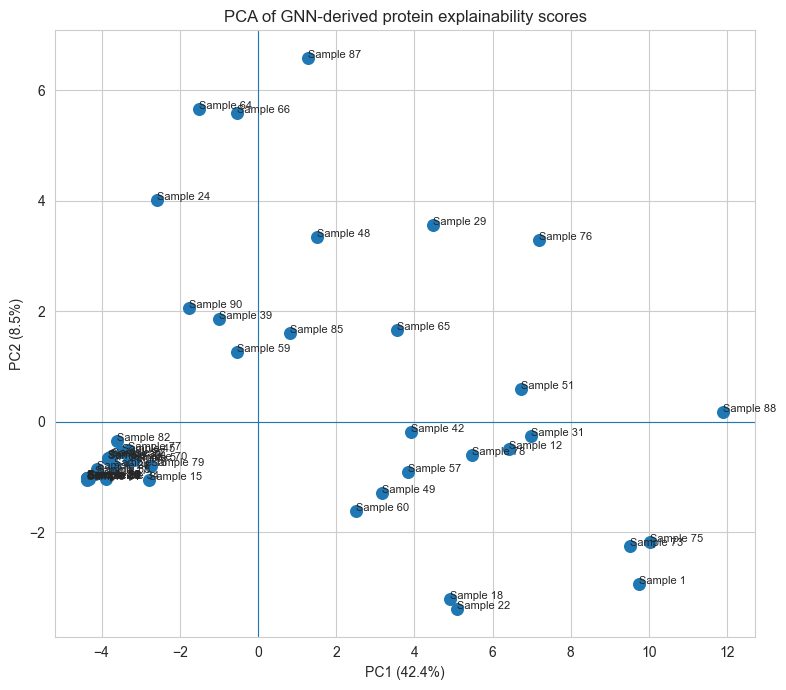

In [30]:
plt.figure(figsize=(8, 7))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    s=70
)

for patient, row in pca_df.iterrows():
    plt.text(
        row["PC1"],
        row["PC2"],
        str(patient),
        fontsize=8
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of GNN-derived protein explainability scores")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.tight_layout()
plt.show()

In [33]:

importance_matrix_plasma = plasma_explanations_df.pivot(
    index="sample",
    columns="gene",
    values="importance"
)
X_plasma = importance_matrix_plasma.values


# remove pathways with missing values
# X = X.dropna(axis=1)

# standardize each pathway across patients
#X_scaled = StandardScaler().fit_transform(X)

# PCA
pca_plasma = PCA(n_components=2)
X_pca_plasma = pca_plasma.fit_transform(X_plasma)

pca_df_plasma = pd.DataFrame(
    X_pca,
    index=importance_matrix_plasma.index,
    columns=["PC1", "PC2"]
)

print("Explained variance:")
print("PC1:", pca_plasma.explained_variance_ratio_[0])
print("PC2:", pca_plasma.explained_variance_ratio_[1])
print("Total:", pca_plasma.explained_variance_ratio_[:2].sum())

Explained variance:
PC1: 0.42162535
PC2: 0.08437704
Total: 0.50600237


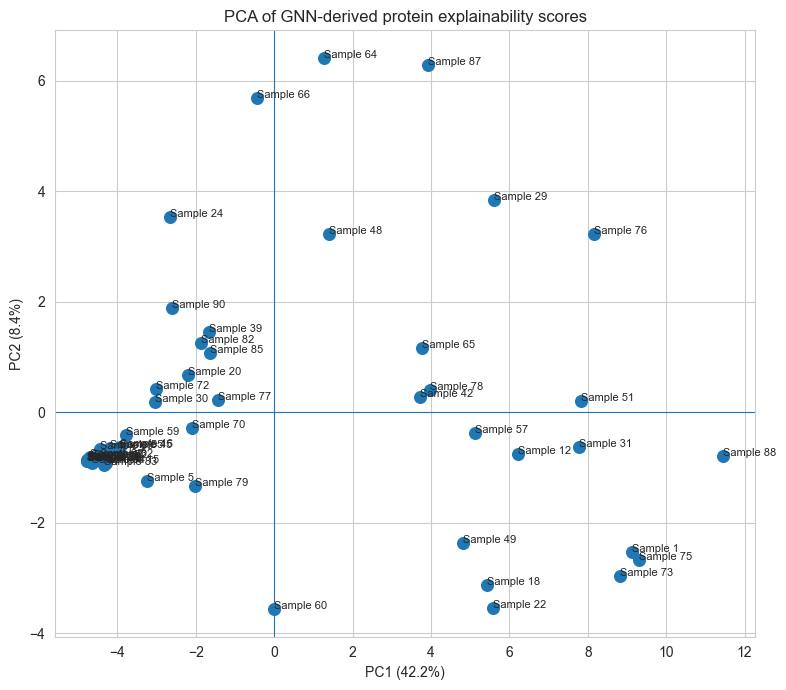

In [34]:

plt.figure(figsize=(8, 7))

plt.scatter(
    pca_df_plasma["PC1"],
    pca_df_plasma["PC2"],
    s=70
)

for patient, row in pca_df_plasma.iterrows():
    plt.text(
        row["PC1"],
        row["PC2"],
        str(patient),
        fontsize=8
    )

plt.xlabel(f"PC1 ({pca_plasma.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca_plasma.explained_variance_ratio_[1] * 100:.1f}%)")
plt.title("PCA of GNN-derived protein explainability scores")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.tight_layout()
plt.show()

In [70]:
pathway_variability = (
    tissue_scores
    .std()
    .sort_values(ascending=False)
)

print(pathway_variability.head(30))

Term
REACTOME_ANTIGEN_PROCESSING_UB_ATP_INDEPENDENT_PROTEASOMAL_DEGRADATION               0.031806
REACTOME_INITIAL_TRIGGERING_OF_COMPLEMENT                                            0.030301
REACTOME_PLASMA_LIPOPROTEIN_ASSEMBLY                                                 0.029611
REACTOME_GRB2_SOS_PROVIDES_LINKAGE_TO_MAPK_SIGNALING_FOR_INTEGRINS                   0.029189
REACTOME_P130CAS_LINKAGE_TO_MAPK_SIGNALING_FOR_INTEGRINS                             0.028541
REACTOME_COMMON_PATHWAY_OF_FIBRIN_CLOT_FORMATION                                     0.028493
REACTOME_COMPLEMENT_CASCADE                                                          0.027857
REACTOME_PLASMA_LIPOPROTEIN_REMODELING                                               0.026700
REACTOME_CELL_EXTRACELLULAR_MATRIX_INTERACTIONS                                      0.026643
REACTOME_INTRINSIC_PATHWAY_OF_FIBRIN_CLOT_FORMATION                                  0.026323
REACTOME_DISEASES_OF_HEMOSTASIS                        

In [75]:
pathway_stats = pd.DataFrame({
    "mean": plasma_scores.mean(),
    "std": plasma_scores.std(),
    "min": plasma_scores.min(),
    "max": plasma_scores.max()
})

pathway_stats = pathway_stats.sort_values(
    "std",
    ascending=False
)

print(pathway_stats.sort_values(by='std',ascending=False).head(30))

                                                        mean       std  \
Term                                                                     
REACTOME_ANTIGEN_PROCESSING_UB_ATP_INDEPENDENT_...  0.153883  0.205712   
REACTOME_FORMATION_OF_THE_CORNIFIED_ENVELOPE       -0.020284  0.195483   
REACTOME_KERATINIZATION                            -0.020284  0.195483   
REACTOME_METABOLISM_OF_FAT_SOLUBLE_VITAMINS        -0.009415  0.192387   
REACTOME_PLASMA_LIPOPROTEIN_REMODELING             -0.015991  0.183749   
REACTOME_INITIAL_TRIGGERING_OF_COMPLEMENT          -0.029681  0.181615   
REACTOME_COMMON_PATHWAY_OF_FIBRIN_CLOT_FORMATION   -0.037321  0.181146   
REACTOME_VISUAL_PHOTOTRANSDUCTION                   0.003289  0.179945   
REACTOME_HEDGEHOG_LIGAND_BIOGENESIS                 0.199731  0.178047   
REACTOME_HH_MUTANTS_ABROGATE_LIGAND_SECRETION       0.195852  0.176779   
REACTOME_AMPK_INDUCED_ERAD_AND_LYSOSOME_MEDIATE...  0.195852  0.176779   
REACTOME_ASYMMETRIC_LOCALIZATION_OF_PC

In [76]:
print(pathway_stats.sort_values(by='mean',ascending=False).head(30))

                                                        mean       std  \
Term                                                                     
REACTOME_RHO_GTPASES_ACTIVATE_WASPS_AND_WAVES       0.290358  0.149489   
REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOC...  0.289764  0.149004   
REACTOME_EPHB_MEDIATED_FORWARD_SIGNALING            0.285405  0.171834   
REACTOME_PARASITE_INFECTION                         0.278843  0.151643   
REACTOME_RHOBTB_GTPASE_CYCLE                        0.275954  0.143693   
REACTOME_COOPERATION_OF_PREFOLDIN_AND_TRIC_CCT_...  0.261423  0.152480   
REACTOME_RHO_GTPASES_ACTIVATE_FORMINS               0.261382  0.166067   
REACTOME_SIGNALING_BY_ALK_IN_CANCER                 0.258456  0.133955   
REACTOME_REGULATION_OF_PLK1_ACTIVITY_AT_G2_M_TR...  0.254061  0.161695   
REACTOME_MITOCHONDRIAL_PROTEIN_DEGRADATION          0.251361  0.142175   
REACTOME_DENGUE_VIRUS_GENOME_TRANSLATION_AND_RE...  0.250759  0.135525   
REACTOME_RHO_GTPASE_EFFECTORS         

<Figure size 1600x1000 with 0 Axes>

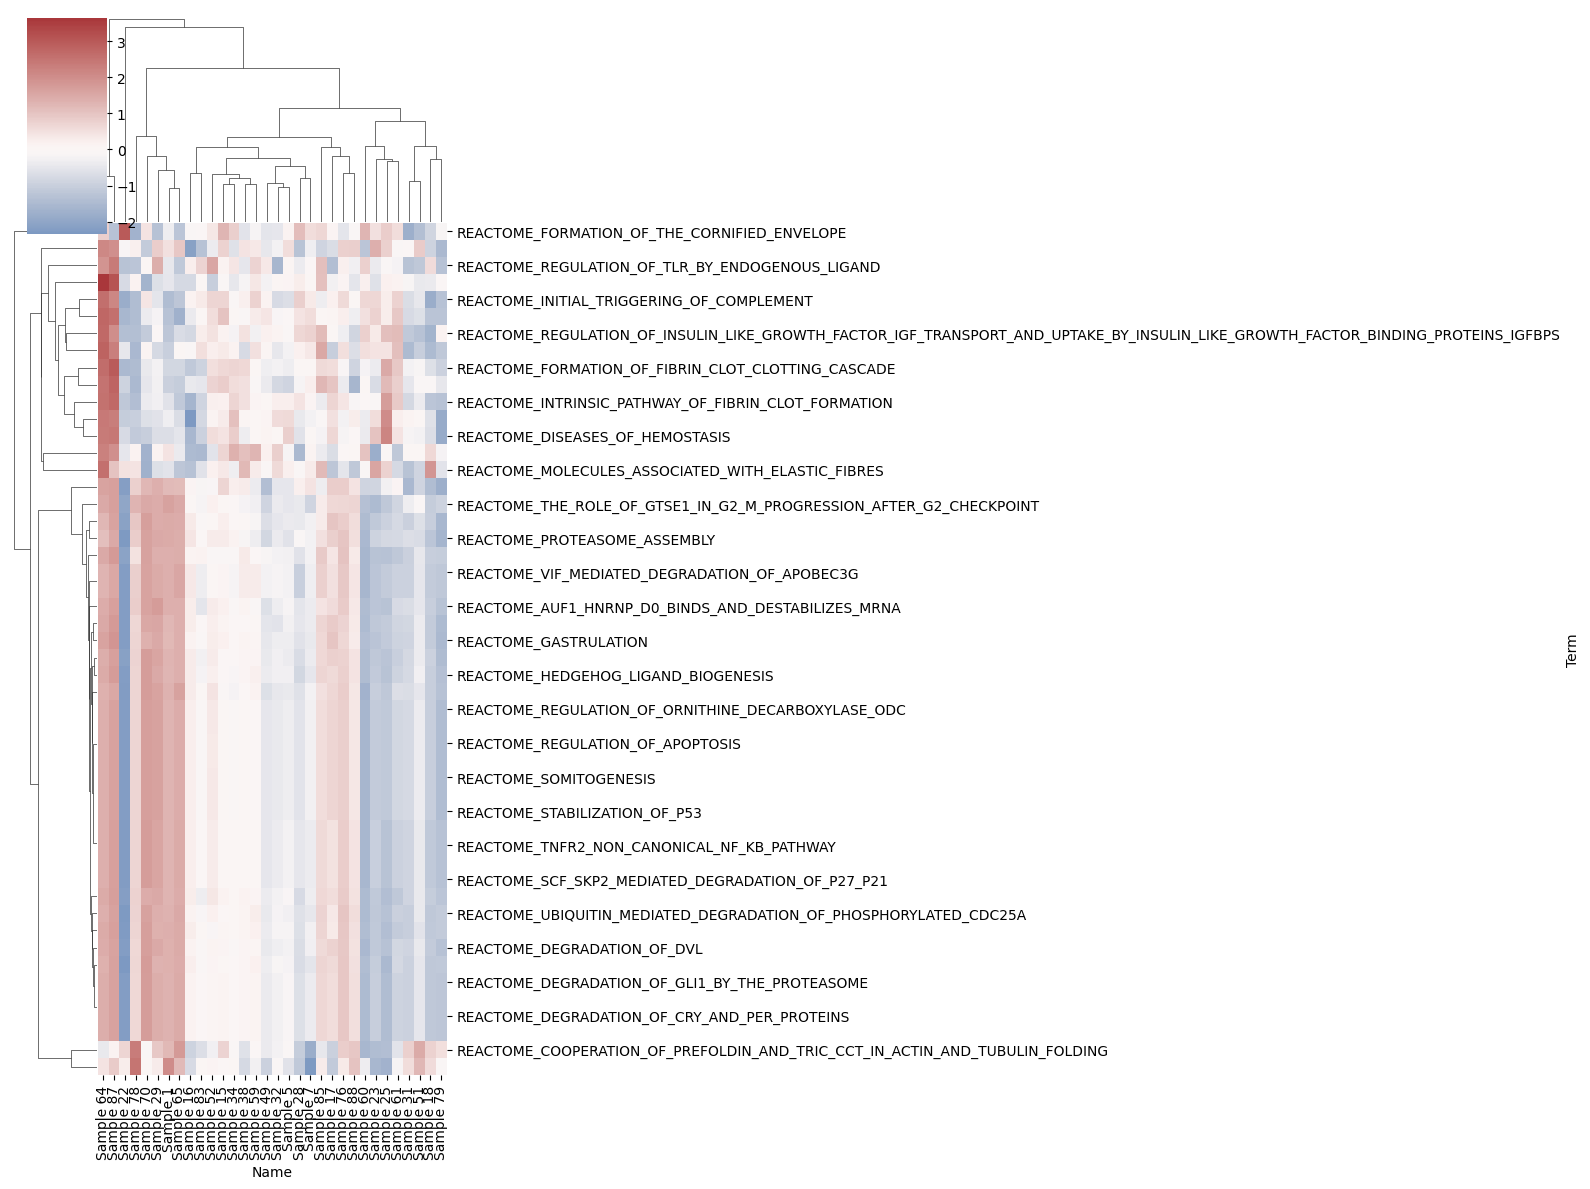

In [82]:
pathway_variability = tissue_scores.mean().sort_values(ascending=False)
top_variable = pathway_variability.head(50).index

variable_scores = tissue_scores[top_variable]
from sklearn.preprocessing import StandardScaler

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(variable_scores),
    index=variable_scores.index,
    columns=variable_scores.columns
)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))

sns.clustermap(
    X_scaled.T,
    cmap="vlag",
    center=0,
    col_cluster=True,
    row_cluster=True,
    figsize=(16, 12)
)

plt.show()